<a href="https://colab.research.google.com/github/RamcharanChandragiri/NATURAL-LANGUAGE-PROCESSING/blob/main/TextClassification_NB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.IMPORT THE REQUIRED LIBRARIES:


In [10]:
# Data handling
import pandas as pd
import numpy as np

# Text preprocessing
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Train-test split
from sklearn.model_selection import train_test_split

# Model building
from sklearn.naive_bayes import MultinomialNB

# Model evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

2.LOAD AND EXPLORE THE DATA

In [13]:
# Load dataset safely
df = pd.read_csv(
    "/content/Amazon_Reviews.csv",
    engine="python",
    encoding="latin-1",
    on_bad_lines="skip"
)

# Display first 5 rows
print(df.head())

# Show columns
print("Columns:", df.columns)

# Dataset size
print("Dataset Size:", df.shape)

# Extract numeric rating
# Fix: Handle NaN values before converting to int
# 1. Use a raw string for regex to avoid SyntaxWarning.
# 2. Extract the digit, which will result in a Series. If no digit, it'll be NaN.
extracted_ratings = df['Rating'].str.extract(r'(\d)', expand=False)

# 3. Convert to numeric, coercing any non-numeric results (like NaN strings) to actual NaN.
df['rating_number'] = pd.to_numeric(extracted_ratings, errors='coerce')

# 4. Drop rows where 'rating_number' is NaN (i.e., couldn't extract or convert a valid digit).
# This is crucial because integers cannot represent NaN.
df.dropna(subset=['rating_number'], inplace=True)

# 5. Now convert to integer. Since NaNs are handled, this should succeed.
df['rating_number'] = df['rating_number'].astype(int)

# Convert rating into sentiment
def convert_sentiment(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

df['sentiment'] = df['rating_number'].apply(convert_sentiment)

# Class distribution
print("Class Distribution:\n", df['sentiment'].value_counts())

      Reviewer Name                     Profile Link Country Review Count  \
0        Eugene ath  /users/66e8185ff1598352d6b3701a      US     1 review   
1  Daniel ohalloran  /users/5d75e460200c1f6a6373648c      GB    9 reviews   
2          p fisher  /users/546cfcf1000064000197b88f      GB   90 reviews   
3         Greg Dunn  /users/62c35cdbacc0ea0012ccaffa      AU    5 reviews   
4     Sheila Hannah  /users/5ddbe429478d88251550610e      GB    8 reviews   

                Review Date                  Rating  \
0  2024-09-16T13:44:26.000Z  Rated 1 out of 5 stars   
1  2024-09-16T18:26:46.000Z  Rated 1 out of 5 stars   
2  2024-09-16T21:47:39.000Z  Rated 1 out of 5 stars   
3  2024-09-17T07:15:49.000Z  Rated 1 out of 5 stars   
4  2024-09-16T18:37:17.000Z  Rated 1 out of 5 stars   

                                      Review Title  \
0       A Store That Doesn't Want to Sell Anything   
1         Had multiple orders one turned up andâ¦   
2                      I informed these repr

3.TEXT PREPROCESSING

In [14]:
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()  # lowercase
    text = re.sub(f"[{string.punctuation}]", "", text)  # remove punctuation
    words = text.split()
    words = [word for word in words if word not in stop_words]  # remove stopwords
    words = [lemmatizer.lemmatize(word) for word in words]  # lemmatization
    return " ".join(words)

df['cleaned_text'] = df['Review Text'].apply(preprocess_text)

print(df[['Review Text', 'cleaned_text']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


                                         Review Text  \
0  I registered on the website, tried to order a ...   
1  Had multiple orders one turned up and driver h...   
2  I informed these reprobates that I WOULD NOT B...   
3  I have bought from Amazon before and no proble...   
4  If I could give a lower rate I would! I cancel...   

                                        cleaned_text  
0  registered website tried order laptop entered ...  
1  multiple order one turned driver phone door nu...  
2  informed reprobate would going visit sick rela...  
3  bought amazon problem happy service price amaz...  
4  could give lower rate would cancelled amazon p...  


4.FEATURE EXTRACTION

In [15]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['cleaned_text'])
y = df['sentiment']

print("Feature Matrix Shape:", X.shape)
print("Sample Feature Names:", vectorizer.get_feature_names_out()[:20])

Feature Matrix Shape: (21055, 5000)
Sample Feature Names: ['000' '10' '100' '1000' '10000' '1010' '10am' '10pm' '10th' '11' '110'
 '1100' '119' '11th' '12' '120' '1200' '125' '1299' '12th']


5.TRAIN TEST SPLIT

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Size:", X_train.shape)
print("Testing Size:", X_test.shape)

Training Size: (16844, 5000)
Testing Size: (4211, 5000)


6.TRAIN NAIVE BAYES CLASSIFIER

In [17]:
model = MultinomialNB()
model.fit(X_train, y_train)

print("Model Parameters:", model.get_params())

Model Parameters: {'alpha': 1.0, 'class_prior': None, 'fit_prior': True, 'force_alpha': True}


7.MODEL EVALUATION

In [19]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8914747090952267
Precision: 0.8558592728136518
Recall: 0.8914747090952267
F1 Score: 0.8718325736832683

Confusion Matrix:
 [[2857    0   64]
 [ 109    0   57]
 [ 227    0  897]]

Classification Report:
               precision    recall  f1-score   support

    Negative       0.89      0.98      0.93      2921
     Neutral       0.00      0.00      0.00       166
    Positive       0.88      0.80      0.84      1124

    accuracy                           0.89      4211
   macro avg       0.59      0.59      0.59      4211
weighted avg       0.86      0.89      0.87      4211



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

PLOT

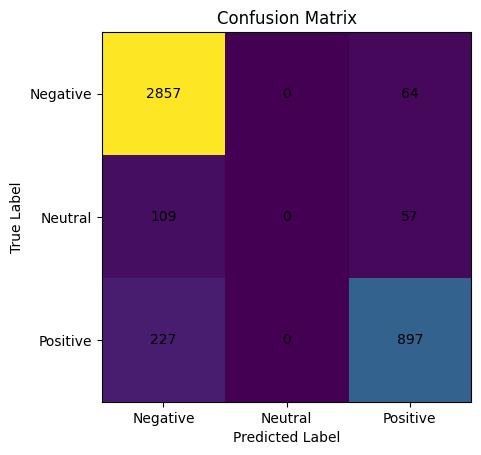

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
classes = model.classes_

# Create plot
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(np.arange(len(classes)), classes)
plt.yticks(np.arange(len(classes)), classes)

# Add numbers inside cells
for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()